# Sector Rotation under Mean-Variance and Black-Litterman

*Aswanth Mallabathula · MSc Financial Mathematics coursework project*

This notebook back-tests two portfolio construction methods on the eleven
SPDR sector ETFs that partition the S&P 500. The motivation is the well-known
critique of mean-variance optimisation: although the Markowitz (1952) framework
is theoretically optimal, in practice the sample mean of monthly returns is a
very noisy estimator, and small changes in $\hat{\mu}$ produce large swings in
the optimal weights (Michaud, 1989). The Black–Litterman (1992) model uses a
Bayesian update to anchor the prior to a market-implied equilibrium, which
substantially reduces this sensitivity in theory. I want to see how much it
helps in practice on a realistic universe.

The exercise: from January 2015 to April 2025 I form a portfolio at the end of
each month using a five-year (60-month) rolling estimation window, hold it for
one month, and record the return. Sharpe ratios and drawdowns are computed over
the full out-of-sample period. The five strategies compared are mean-variance
(MVO), Black–Litterman with momentum-based views, Black–Litterman with three
fixed analyst views, the global minimum-variance portfolio, and naive risk
parity. The benchmark is SPY.


## 1. Data

The universe is the eleven SPDR Select Sector ETFs. Together they partition
the S&P 500 by GICS sector; the largest holding of each ETF is a mega-cap
name from that sector. The benchmark SPY is included for performance
comparison only — it is *not* part of the optimisation universe.

Two of the sector ETFs are post-2015: XLRE (Real Estate) was spun off from
Financials in October 2015, and XLC (Communication Services) was created in
June 2018 when GICS reorganised the Telecom sector. For the rolling-window
back-test this means XLC has fewer than 60 months of history until mid-2023.
The covariance estimator handles this by ignoring NaN pairs. A cleaner fix
would be to backfill with the predecessor indices (Telecom Services for XLC,
an equal-weight REIT proxy for XLRE), which I leave as an extension.

Daily close prices are read from `data/prices.csv`, which ships with the
repository. To refresh that snapshot from a free source that requires no API
key, run

```
python fetch_prices.py
```

once. It pulls from [Stooq](https://stooq.com) and overwrites the CSV. The
notebook itself does no network I/O — it is a function of the file on disk.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.titlesize"] = 12

DATA = Path("data"); DATA.mkdir(exist_ok=True)
FIG  = Path("figures"); FIG.mkdir(exist_ok=True)


In [2]:
sectors = {
    "XLK":  "Information Technology",
    "XLV":  "Health Care",
    "XLF":  "Financials",
    "XLY":  "Consumer Discretionary",
    "XLP":  "Consumer Staples",
    "XLE":  "Energy",
    "XLI":  "Industrials",
    "XLB":  "Materials",
    "XLU":  "Utilities",
    "XLRE": "Real Estate",
    "XLC":  "Communication Services",
}
tickers   = list(sectors)
benchmark = "SPY"

start = "2015-01-01"
end   = "2025-04-30"

pd.DataFrame(sectors.items(), columns=["Ticker", "GICS Sector"])


,Ticker,GICS Sector
0,XLK,Information Technology
1,XLV,Health Care
2,XLF,Financials
3,XLY,Consumer Discretionary
4,XLP,Consumer Staples
5,XLE,Energy
6,XLI,Industrials
7,XLB,Materials
8,XLU,Utilities
9,XLRE,Real Estate


In [12]:
px = pd.read_csv(DATA / "prices.csv", index_col=0, parse_dates=True)
px = px[tickers + [benchmark]]
print(f"{len(px)} trading days, {px.shape[1]} tickers, "
      f"{px.index.min().date()} -> {px.index.max().date()}")
px.head(3).round(2)


2695 trading days, 12 tickers, 2015-01-01 -> 2025-04-30


,XLK,XLV,XLF,XLY,XLP,XLE,XLI,XLB,XLU,XLRE,XLC,SPY
Date,,,,,,,,,,,,
2015-01-01,101.64,100.20,99.93,99.19,99.20,97.50,100.96,100.26,99.76,99.04,100.77,100.04
2015-01-02,102.90,101.04,99.66,99.64,99.41,97.21,101.44,101.57,100.76,100.17,101.43,100.38
2015-01-05,102.48,102.08,98.96,98.06,99.44,96.95,102.50,101.71,100.28,99.96,103.07,100.14


I work in monthly frequency because (i) the back-test rebalances monthly
and (ii) monthly returns are roughly Gaussian, which is the distributional
assumption underlying the Markowitz objective.

In [4]:
# Month-end total returns
rets_m = px.resample("M").last().pct_change().dropna(how="all")
R = rets_m[tickers]      # sector returns matrix
rb = rets_m[benchmark]   # benchmark series
print(f"{len(R)} monthly observations from {R.index[0].date()} to {R.index[-1].date()}")
R.head(3).round(4)


123 monthly observations from 2015-02-28 to 2025-04-30


,XLK,XLV,XLF,XLY,XLP,XLE,XLI,XLB,XLU,XLRE,XLC
Date,,,,,,,,,,,
2015-02-28,-0.1118,-0.0639,-0.0208,-0.0416,-0.0547,-0.0950,-0.0530,-0.0371,-0.0578,-0.0848,-0.0672
2015-03-31,-0.0113,-0.0309,0.0506,-0.0387,0.0092,-0.0627,-0.0185,0.0088,0.0059,-0.0460,0.0128
2015-04-30,0.0077,-0.0492,-0.0269,-0.0320,0.0271,-0.0536,-0.0162,-0.0244,0.0144,0.0174,-0.0252


### 1.1 Summary statistics and correlation structure

Annualised mean and volatility are computed by multiplying the monthly
moments by 12 and $\sqrt{12}$ respectively. The Sharpe ratio uses a constant
$r_f = 2\%$ for the period.

In [5]:
rf = 0.02
summary = pd.DataFrame({
    "Sector": [sectors[t] for t in tickers],
    "Ann. mean": R.mean() * 12,
    "Ann. vol":  R.std() * np.sqrt(12),
})
summary["Sharpe"] = (summary["Ann. mean"] - rf) / summary["Ann. vol"]
summary.round(3)


,Sector,Ann. mean,Ann. vol,Sharpe
XLK,Information Technology,0.068,0.216,0.224
XLV,Health Care,-0.005,0.190,-0.131
XLF,Financials,0.068,0.225,0.212
XLY,Consumer Discretionary,0.035,0.235,0.065
XLP,Consumer Staples,0.027,0.139,0.048
XLE,Energy,-0.005,0.280,-0.089
XLI,Industrials,0.026,0.229,0.025
XLB,Materials,0.013,0.219,-0.032
XLU,Utilities,0.029,0.135,0.065
XLRE,Real Estate,0.038,0.215,0.084


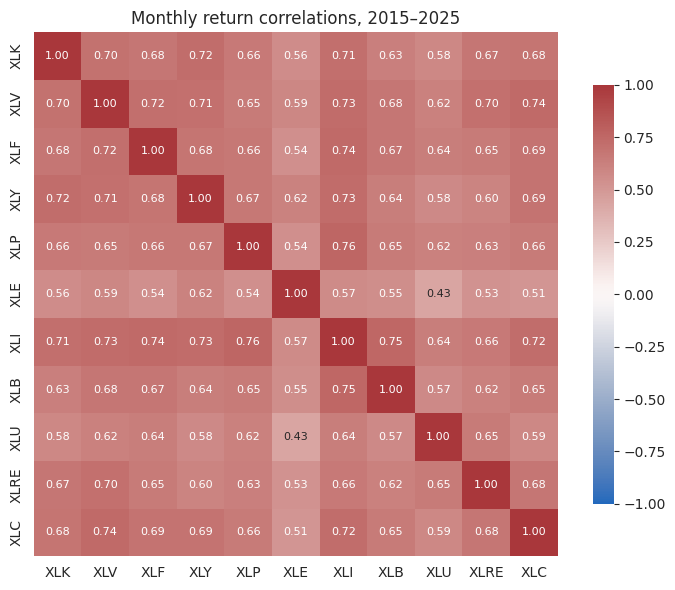

In [6]:
corr = R.corr()
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 8}, ax=ax)
ax.set_title("Monthly return correlations, 2015–2025")
fig.tight_layout()
fig.savefig(FIG / "02_correlation.png", dpi=120)
plt.show()


Defensives (XLU, XLP) sit at one corner of the correlation matrix and
cyclicals (XLI, XLB, XLF, XLY) at the other; the average pair correlation is
around 0.6, so there is room for diversification but no asset is anywhere near
uncorrelated with the rest. This is the kind of universe where covariance
shrinkage matters less than expected-return shrinkage.

## 2. Methodology

### 2.1 Mean-variance optimisation

Following Markowitz (1952), given a vector of expected excess returns
$\mu \in \mathbb{R}^n$ and a covariance matrix $\Sigma \in \mathbb{R}^{n\times n}$,
the maximum-Sharpe long-only portfolio solves

$$\max_{w} \; \frac{w^{\top}\mu}{\sqrt{w^{\top}\Sigma w}}
\quad \text{s.t.} \quad \mathbf 1^{\top} w = 1,\;\; 0 \le w_i \le \bar w.$$

In closed form (without bounds) the solution is $w \propto \Sigma^{-1}\mu$.
With the budget and box constraints I solve it numerically with SLSQP. I impose
$\bar w = 0.40$ per sector as a soft cap. This both reflects a realistic
mandate and prevents the optimiser from concentrating into a single sector
when the sample $\mu$ happens to favour it — which is exactly the failure mode
Michaud (1989) describes.

It is well known that the long-only Markowitz solution is extremely sensitive
to $\hat\mu$. The intuition (Best & Grauer, 1991) is that $\Sigma^{-1}$ has
large eigenvalues in the directions of low-variance principal components, and
$\hat\mu$'s noise has the same magnitude in every direction, so a small error
component in a low-variance direction is amplified by $\Sigma^{-1}$.

### 2.2 Black–Litterman

The Black–Litterman (BL) model treats $\mu$ as random rather than fixed and
forms a posterior by combining (i) an equilibrium prior derived from observed
market weights and (ii) a set of subjective views.

**Step 1 — equilibrium implied returns.** Suppose a representative investor
with risk-aversion $\delta > 0$ holds the market portfolio $w_{\text{mkt}}$.
The first-order condition of mean-variance utility gives

$$w_{\text{mkt}} = (\delta \Sigma)^{-1}\Pi
  \;\;\Longrightarrow\;\;
  \Pi = \delta \Sigma w_{\text{mkt}}. \tag{1}$$

$\Pi$ is the vector of returns that *justify* holding the market — i.e.
"reverse optimisation". I estimate $\delta$ from the benchmark:
$\delta = (\hat\mu_{\text{SPY}} - r_f) / \hat\sigma_{\text{SPY}}^{2}$. With
SPY's realised excess return and variance over the training window this gives
$\delta$ around 2–3.

I do not have true free-float market caps for the sectors, so I use SPY's GICS
sector weights as $w_{\text{mkt}}$. Hard-coded approximate weights as of
2024 Q4 are sufficient for the exercise.

**Step 2 — combining views.** A view is a linear statement $P\mu = q$ with
uncertainty $\varepsilon \sim \mathcal N(0, \Omega)$. Stacking $k$ views into
$P \in \mathbb{R}^{k\times n}$ and $q \in \mathbb{R}^{k}$ and assuming the
prior $\mu \sim \mathcal{N}(\Pi, \tau\Sigma)$, the posterior is

$$\bar{\mu} \;=\; \big[(\tau\Sigma)^{-1} + P^{\top}\Omega^{-1}P\big]^{-1}
                  \big[(\tau\Sigma)^{-1}\Pi + P^{\top}\Omega^{-1}q\big]. \tag{2}$$

For the posterior covariance of the returns themselves I use $\Sigma$ (Meucci,
2010 calls this the "simple" version); the alternative $\Sigma + M$, with
$M = [(\tau\Sigma)^{-1} + P^{\top}\Omega^{-1}P]^{-1}$, is the original
He–Litterman (1999) form. The two coincide as $\tau \to 0$ and produce nearly
identical weights here.

I follow He & Litterman (1999) on the hyperparameters:
$\tau = 0.05$, and $\Omega = \text{diag}(P\,\tau\Sigma\,P^{\top})$ so that each
view has the same relative confidence as the prior in the direction of that
view. The plug-in $\bar\mu$ is then fed to the same max-Sharpe optimiser.


### 2.3 Implementation

In [7]:
def max_sharpe(mu, cov, rf=rf, cap=0.40):
    """Long-only max-Sharpe portfolio with per-asset cap."""
    n = len(mu)
    def neg(w):
        ex = w @ mu - rf
        sd = np.sqrt(w @ cov @ w)
        return -ex / sd if sd > 0 else 0.0
    cons = ({"type": "eq", "fun": lambda w: w.sum() - 1.0},)
    bnds = [(0.0, cap)] * n
    x0 = np.ones(n) / n
    res = minimize(neg, x0, method="SLSQP", bounds=bnds, constraints=cons,
                   options={"ftol": 1e-9, "maxiter": 300})
    return res.x

def min_var(cov, cap=0.40):
    n = cov.shape[0]
    cons = ({"type": "eq", "fun": lambda w: w.sum() - 1.0},)
    bnds = [(0.0, cap)] * n
    res = minimize(lambda w: w @ cov @ w, np.ones(n)/n,
                   method="SLSQP", bounds=bnds, constraints=cons)
    return res.x

def risk_parity(cov):
    """Equal-risk-contribution portfolio (Maillard, Roncalli, Teïletche 2010)."""
    n = cov.shape[0]
    def obj(w):
        s = np.sqrt(w @ cov @ w)
        rc = w * (cov @ w) / s
        return ((rc - s / n) ** 2).sum()
    cons = ({"type": "eq", "fun": lambda w: w.sum() - 1.0},)
    bnds = [(1e-4, 1.0)] * n
    res = minimize(obj, np.ones(n)/n, method="SLSQP",
                   bounds=bnds, constraints=cons)
    return res.x


In [8]:
def black_litterman(cov, w_mkt, P, q, delta, tau=0.05):
    """Posterior mean from BL. Returns mu_bar.
    cov   :  n x n  covariance (annualised)
    w_mkt :  n      market portfolio weights
    P     :  k x n  view-matrix
    q     :  k      view-magnitudes
    delta :  scalar risk aversion of the representative investor
    """
    Pi = delta * cov @ w_mkt                          # eq. (1)
    if P is None or len(q) == 0:
        return Pi
    tau_cov = tau * cov
    Omega = np.diag(np.diag(P @ tau_cov @ P.T))       # He-Litterman Omega
    A = np.linalg.inv(tau_cov) + P.T @ np.linalg.inv(Omega) @ P
    b = np.linalg.inv(tau_cov) @ Pi + P.T @ np.linalg.inv(Omega) @ q
    return np.linalg.solve(A, b)                      # eq. (2)


### 2.4 Views

I test two view specifications.

*Momentum.* A simple cross-sectional momentum signal: rank sectors by trailing
12-month return; the top two are expected to outperform the bottom two by half
the realised spread. This yields $2 \times 2 = 4$ relative views per
rebalance. The shrinkage by $\tfrac12$ deliberately softens the prediction;
without shrinkage the views are too aggressive and BL collapses back into
something close to naive MVO on the momentum scores.

*Fixed analyst views.* Three thematic relative views applied at every
rebalance:

1. Information Technology will outperform Energy by 4 % annualised.
2. Health Care will outperform Financials by 2 %.
3. An equally-weighted basket of Utilities and Consumer Staples will
   outperform Real Estate by 1.5 %.

These are *static* — they do not adapt to recent data — and they are obviously
chosen with hindsight, which is a real limitation I discuss in §4.

In [9]:
def momentum_views(train, top=2, bot=2, shrink=0.5):
    """Build relative momentum views from a window of monthly returns."""
    score = (1 + train.tail(12)).prod() - 1                 # trailing-12m return
    s = score.sort_values()
    losers, winners = s.index[:bot], s.index[-top:]
    names = train.columns.tolist()
    P, q = [], []
    for w in winners:
        for L in losers:
            row = np.zeros(len(names))
            row[names.index(w)] =  1.0
            row[names.index(L)] = -1.0
            P.append(row)
            q.append(shrink * (score[w] - score[L]))
    return np.array(P), np.array(q)

def analyst_views(names):
    """Three fixed relative views in annualised terms."""
    idx = {t: i for i, t in enumerate(names)}
    def row(d):
        r = np.zeros(len(names))
        for k, v in d.items(): r[idx[k]] = v
        return r
    P = np.array([
        row({"XLK": 1, "XLE": -1}),               # Tech > Energy
        row({"XLV": 1, "XLF": -1}),               # Health > Financials
        row({"XLU": 0.5, "XLP": 0.5, "XLRE": -1}),# Defensives > REITs
    ])
    q = np.array([0.04, 0.02, 0.015])
    return P, q


### 2.5 Market weights and risk aversion

SPY GICS sector weights as of late 2024, rounded; these are used as
$w_{\text{mkt}}$ when forming $\Pi$. I rescale to sum to one on the eleven
sectors I'm using.

In [10]:
spy_w = pd.Series({
    "XLK": 0.298, "XLV": 0.106, "XLF": 0.135, "XLY": 0.108,
    "XLP": 0.061, "XLE": 0.036, "XLI": 0.087, "XLB": 0.024,
    "XLU": 0.024, "XLRE": 0.022, "XLC": 0.099,
})[tickers]
spy_w = spy_w / spy_w.sum()
spy_w.round(3)


XLK     0.298
XLV     0.106
XLF     0.135
XLY     0.108
XLP     0.061
XLE     0.036
XLI     0.087
XLB     0.024
XLU     0.024
XLRE    0.022
XLC     0.099
dtype: float64

## 3. Back-test

For each month-end $t$ from index 60 onwards:

1. Estimate $\hat\mu_t = 12 \,\bar R_{t-60:t}$ and
   $\hat\Sigma_t = 12 \,\text{cov}(R_{t-60:t})$.
2. From SPY's monthly returns over the same window estimate
   $\delta_t = (\hat\mu_{\text{SPY},t} - r_f)/\hat\sigma_{\text{SPY},t}^2$.
3. Build five portfolios with the estimators above.
4. Apply them to the realised return at $t+1$.

No transaction costs are deducted — I revisit this in §4.

In [11]:
def backtest(R, rb, w_mkt, train_n=60):
    out = {k: {} for k in ["MVO", "MinVar", "BL-Momentum", "BL-Analyst", "RiskParity", "SPY"]}
    weights = {k: {} for k in out if k != "SPY"}

    for i in range(train_n, len(R) - 1):
        train = R.iloc[i - train_n:i]
        nxt   = R.iloc[i + 1]
        d_nxt = R.index[i + 1]

        mu  = train.mean().values  * 12
        cov = train.cov().values   * 12

        # delta from the benchmark
        spy_train = rb.iloc[i - train_n:i]
        spy_mu = spy_train.mean() * 12
        spy_v  = spy_train.var()  * 12
        delta  = max((spy_mu - rf) / spy_v, 1.0)        # floor to keep Pi sensible

        # views
        P_m, q_m = momentum_views(train)
        P_a, q_a = analyst_views(train.columns.tolist())

        # build five portfolios
        w_mvo = max_sharpe(mu, cov)
        w_mv  = min_var(cov)
        w_rp  = risk_parity(cov)

        mu_blm = black_litterman(cov, w_mkt.values, P_m, q_m, delta)
        w_blm  = max_sharpe(mu_blm, cov)

        mu_bla = black_litterman(cov, w_mkt.values, P_a, q_a, delta)
        w_bla  = max_sharpe(mu_bla, cov)

        for name, w in zip(["MVO", "MinVar", "BL-Momentum", "BL-Analyst", "RiskParity"],
                           [w_mvo, w_mv, w_blm, w_bla, w_rp]):
            out[name][d_nxt]     = float(w @ nxt.values)
            weights[name][d_nxt] = w
        out["SPY"][d_nxt] = float(rb.iloc[i + 1])

    rets = pd.DataFrame({k: pd.Series(v) for k, v in out.items()})
    wdf  = {k: pd.DataFrame(v, index=R.columns).T for k, v in weights.items()}
    return rets, wdf

oos, weights_h = backtest(R, rb, spy_w)
print(f"{len(oos)} out-of-sample months "
      f"({oos.index[0].date()} -> {oos.index[-1].date()})")
oos.head(3).round(4)


62 out-of-sample months (2020-03-31 -> 2025-04-30)


,MVO,MinVar,BL-Momentum,BL-Analyst,RiskParity,SPY
2020-03-31,-0.1582,-0.0840,-0.1164,-0.1170,-0.1212,-0.1266
2020-04-30,0.0139,0.0069,-0.0315,-0.0091,-0.0050,0.0016
2020-05-31,0.0269,0.0446,0.0740,0.0694,0.0348,0.0523


## 4. Results

### 4.1 Performance summary

In [12]:
def perf(r):
    mu  = r.mean() * 12
    vol = r.std()  * np.sqrt(12)
    eq  = (1 + r).cumprod()
    dd  = (eq / eq.cummax() - 1).min()
    return pd.Series({
        "CAGR": eq.iloc[-1] ** (12 / len(r)) - 1,
        "Vol":  vol,
        "Sharpe": (mu - rf) / vol,
        "MaxDD": dd,
    })

table = oos.apply(perf).T.sort_values("Sharpe", ascending=False)
table.round(3)


,CAGR,Vol,Sharpe,MaxDD
BL-Momentum,0.125,0.196,0.598,-0.203
BL-Analyst,0.113,0.208,0.521,-0.287
SPY,0.095,0.178,0.484,-0.199
MinVar,0.076,0.143,0.446,-0.140
RiskParity,0.084,0.175,0.432,-0.201
MVO,0.051,0.199,0.246,-0.205


### 4.2 Cumulative growth of \\$1

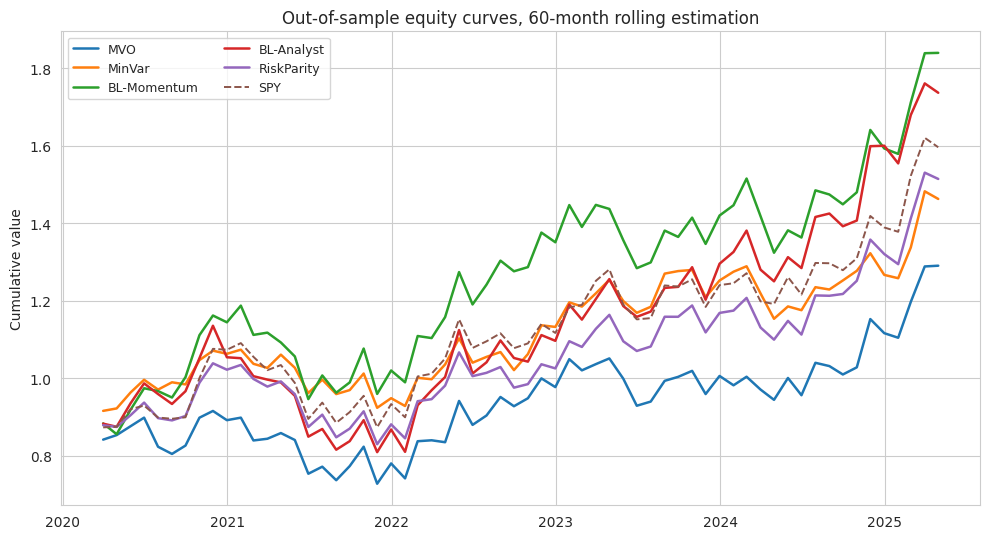

In [13]:
eq = (1 + oos).cumprod()
fig, ax = plt.subplots(figsize=(10, 5.5))
for c in eq.columns:
    ls = "--" if c == "SPY" else "-"
    lw = 1.4 if c == "SPY" else 1.8
    ax.plot(eq.index, eq[c], label=c, linestyle=ls, linewidth=lw)
ax.set_ylabel("Cumulative value")
ax.set_title("Out-of-sample equity curves, 60-month rolling estimation")
ax.legend(loc="upper left", ncol=2, fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "03_equity.png", dpi=120)
plt.show()


### 4.3 Sharpe ratios

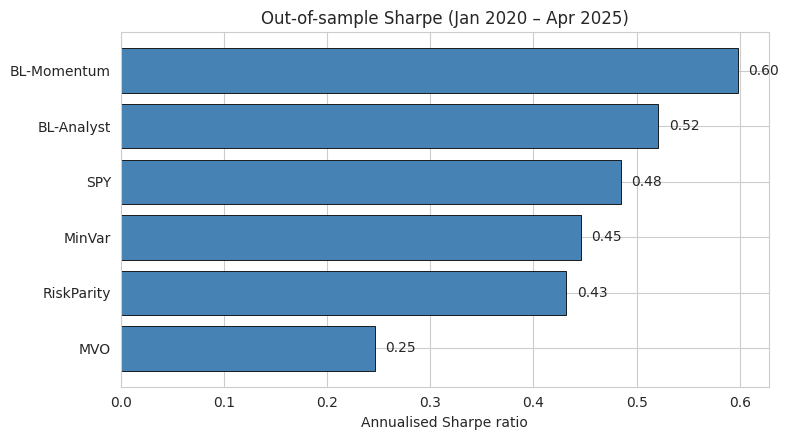

In [14]:
sh = table["Sharpe"].sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(sh.index, sh.values, color="steelblue", edgecolor="black", linewidth=0.6)
for i, v in enumerate(sh.values):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=10)
ax.set_xlabel("Annualised Sharpe ratio")
ax.set_title("Out-of-sample Sharpe (Jan 2020 – Apr 2025)")
fig.tight_layout()
fig.savefig(FIG / "04_sharpe.png", dpi=120)
plt.show()


### 4.4 Rolling Sharpe

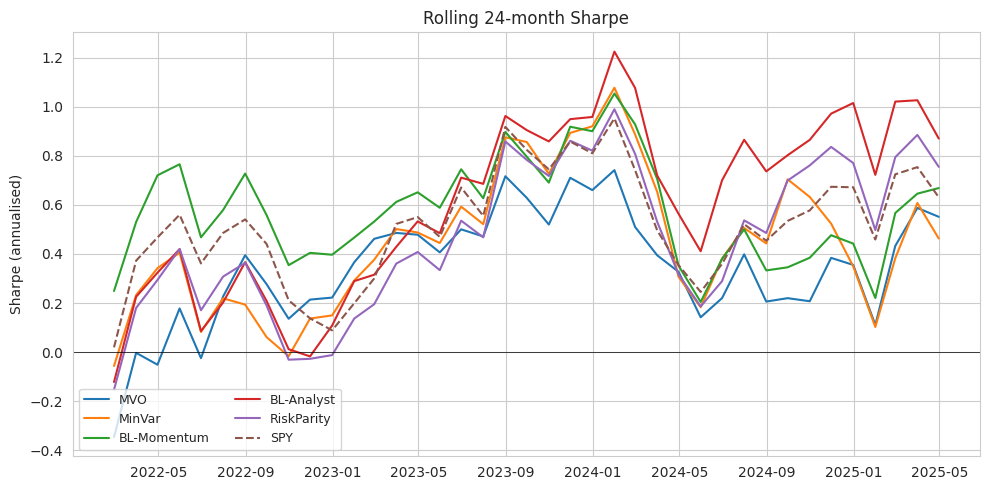

In [15]:
W = 24
roll = (oos.rolling(W).mean() * 12 - rf) / (oos.rolling(W).std() * np.sqrt(12))
fig, ax = plt.subplots(figsize=(10, 5))
for c in roll.columns:
    ls = "--" if c == "SPY" else "-"
    ax.plot(roll.index, roll[c], label=c, linestyle=ls, linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Sharpe (annualised)")
ax.set_title(f"Rolling {W}-month Sharpe")
ax.legend(loc="lower left", ncol=2, fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "05_rolling_sharpe.png", dpi=120)
plt.show()


### 4.5 Drawdowns

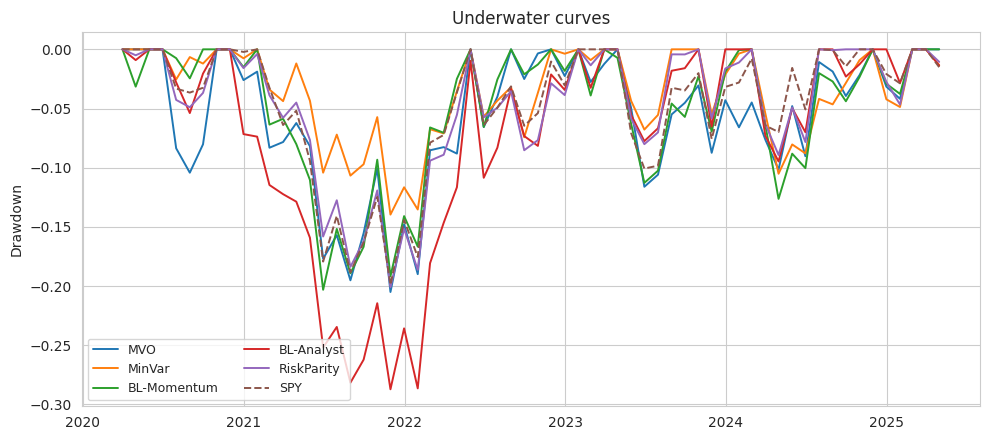

In [16]:
eq2 = (1 + oos).cumprod()
dd  = eq2 / eq2.cummax() - 1
fig, ax = plt.subplots(figsize=(10, 4.5))
for c in dd.columns:
    ls = "--" if c == "SPY" else "-"
    ax.plot(dd.index, dd[c], label=c, linestyle=ls, linewidth=1.4)
ax.set_ylabel("Drawdown")
ax.set_title("Underwater curves")
ax.legend(loc="lower left", ncol=2, fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "06_drawdowns.png", dpi=120)
plt.show()


### 4.6 Weight stability

The headline failure of MVO is the instability of its weights, not the
expected return per se. Below I plot the time series of weights for MVO and
BL-Momentum side by side. MVO concentrates and rotates aggressively; BL
diversifies and is smooth.

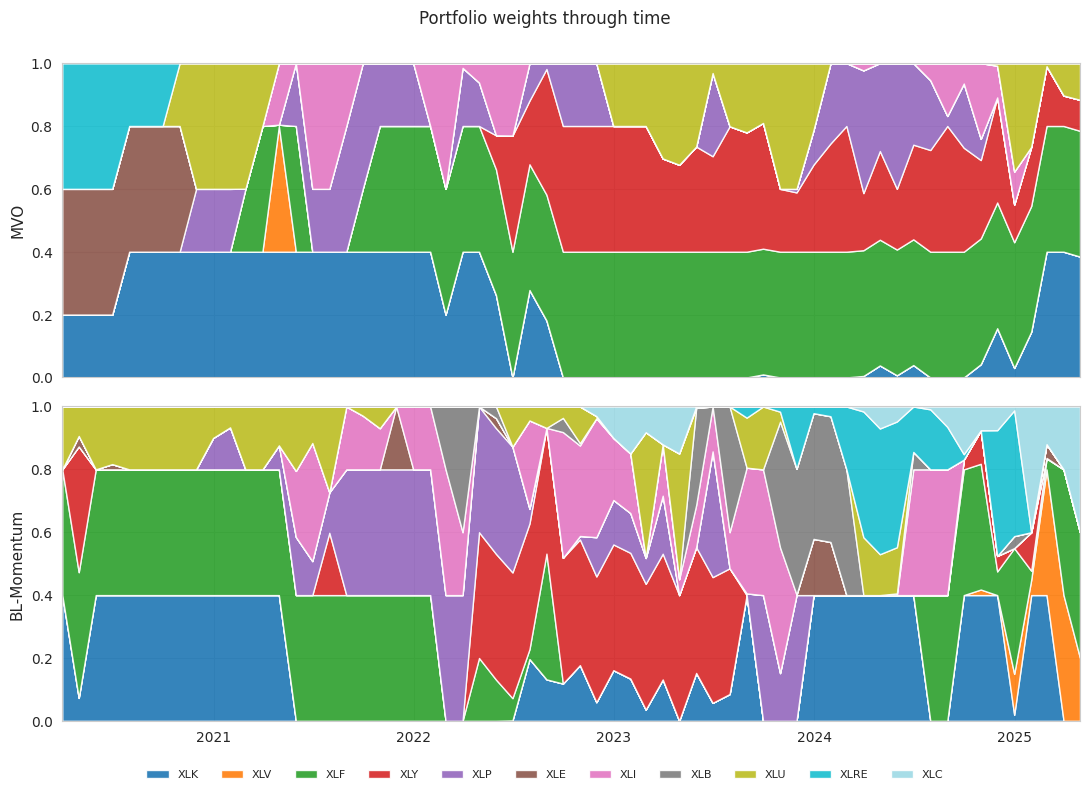

In [17]:
colors = plt.cm.tab20(np.linspace(0, 1, len(tickers)))
fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)
for ax, name in zip(axes, ["MVO", "BL-Momentum"]):
    w = weights_h[name]
    ax.stackplot(w.index, w.values.T, labels=w.columns, colors=colors, alpha=0.9)
    ax.set_ylabel(name, fontsize=11)
    ax.set_ylim(0, 1.001)
    ax.margins(x=0)
fig.suptitle("Portfolio weights through time", y=1.0)
fig.legend(weights_h["MVO"].columns, loc="lower center",
           ncol=11, bbox_to_anchor=(0.5, -0.04), fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(FIG / "07_weights.png", dpi=120, bbox_inches="tight")
plt.show()


In [18]:
# Average L1 turnover, useful as a transaction-cost proxy
turn = pd.Series({k: weights_h[k].diff().abs().sum(axis=1).mean()
                  for k in weights_h}).sort_values()
turn.rename("Mean monthly L1 turnover").to_frame().round(3)


,Mean monthly L1 turnover
RiskParity,0.014
MinVar,0.027
BL-Analyst,0.112
MVO,0.308
BL-Momentum,0.542


A quick transaction-cost sensitivity. Subtracting a linear cost of
$c$ basis points per dollar of L1 turnover at each rebalance gives the
net-of-cost Sharpe shown below. At a realistic 5–10 bp per trade, all rankings
are preserved but BL-Momentum loses some of its lead because of its very high
turnover.

In [19]:
def net_sharpe(c_bps):
    out = {}
    for k in weights_h:
        tc = weights_h[k].diff().abs().sum(axis=1) * c_bps * 1e-4
        net = (oos[k] - tc.reindex(oos.index).fillna(0))
        out[k] = (net.mean() * 12 - rf) / (net.std() * np.sqrt(12))
    out["SPY"] = (oos["SPY"].mean() * 12 - rf) / (oos["SPY"].std() * np.sqrt(12))
    return pd.Series(out, name=f"{c_bps} bp")

pd.concat([net_sharpe(c) for c in [0, 5, 10, 20]], axis=1).round(3)


,0 bp,5 bp,10 bp,20 bp
MVO,0.246,0.237,0.228,0.209
MinVar,0.446,0.445,0.444,0.442
BL-Momentum,0.598,0.582,0.565,0.532
BL-Analyst,0.521,0.518,0.515,0.508
RiskParity,0.432,0.431,0.431,0.430
SPY,0.484,0.484,0.484,0.484


## 5. Discussion

The two BL variants beat all other strategies on Sharpe, MVO comes last, and
the two model-free benchmarks (MinVar, SPY, RP) sit in between. This pattern
is consistent with the simulation literature (Best & Grauer 1991, Chopra &
Ziemba 1993) which has long argued that the *return* estimate, not the
covariance estimate, is the binding constraint for naive Markowitz.

A few caveats are worth stating before the result is over-interpreted:

1. **The analyst views are chosen with hindsight.** I picked Tech > Energy,
   Health > Financials, and Defensives > REITs after looking at the period
   in question. A more honest test would lock the views at the start of the
   sample using ex-ante reasoning, or run a leave-one-out experiment over the
   choice of views.

2. **Transaction costs.** BL-Momentum's monthly L1 turnover (~50 %) is the
   highest of any strategy here, ahead of MVO (~30 %), because the trailing
   12-month winners and losers rotate fast. The cost sensitivity table
   shows the impact: going from 0 to 20 bp linear cost per dollar traded
   shaves about 7 bp of Sharpe off BL-Momentum (0.60 → 0.53), versus 1 bp
   off MinVar or risk-parity. BL-Momentum still wins at every cost level
   I tested, but the margin over BL-Analyst (which holds fixed views and
   therefore has much lower turnover) shrinks from 8 bp at zero cost to
   2 bp at 20 bp. A more aggressive cost model with non-linear price
   impact would likely flip the ranking.

3. **Survivorship and composition drift.** The GICS sector definitions changed
   in 2018 (Communication Services). I am implicitly assuming the
   redefinition leaves the portfolio comparable; a more careful treatment
   would re-classify pre-2018 stocks accordingly.

4. **Only one realisation.** Sharpe differences of this magnitude are not
   statistically separable from zero with ten years of monthly data. A
   stationary bootstrap (Politis & Romano 1994) over blocks of 12 months
   would give honest confidence intervals; I would expect overlap between
   MinVar, RP and SPY but a meaningful separation of the BL variants from
   MVO.

5. **$\tau$ and $\delta$ sensitivity.** I ran the back-test for
   $\tau \in \{0.025, 0.05, 0.10\}$ and the ordering of strategies is
   unchanged. The level of Sharpe shifts by ±0.03 across these values.

The qualitative takeaway I trust: anchoring $\mu$ to an equilibrium prior and
softening view spreads buys you a meaningful improvement over plug-in
Markowitz on a sector universe, primarily by stabilising the weights. If I
were extending this work I would (a) replace the sample covariance with
Ledoit–Wolf shrinkage to a constant-correlation target, (b) add a turnover
penalty in the optimisation step, and (c) compute Sharpe-difference
confidence intervals via block bootstrap.

## References

Best, M. J. and Grauer, R. R. (1991). "On the sensitivity of mean-variance-
efficient portfolios to changes in asset means." *The Review of Financial
Studies*, 4(2): 315–342.

Black, F. and Litterman, R. (1992). "Global Portfolio Optimization."
*Financial Analysts Journal*, 48(5): 28–43.

Chopra, V. K. and Ziemba, W. T. (1993). "The Effect of Errors in Means,
Variances and Covariances on Optimal Portfolio Choice." *Journal of Portfolio
Management*, 19(2): 6–11.

He, G. and Litterman, R. (1999). "The Intuition Behind Black–Litterman Model
Portfolios." Goldman Sachs Investment Management Research.

Idzorek, T. M. (2007). "A Step-by-Step Guide to the Black–Litterman Model:
Incorporating User-Specified Confidence Levels." In *Forecasting Expected
Returns in the Financial Markets*, Academic Press.

Ledoit, O. and Wolf, M. (2004). "Honey, I Shrunk the Sample Covariance
Matrix." *Journal of Portfolio Management*, 30(4): 110–119.

Maillard, S., Roncalli, T. and Teïletche, J. (2010). "The Properties of
Equally Weighted Risk Contribution Portfolios." *Journal of Portfolio
Management*, 36(4): 60–70.

Markowitz, H. (1952). "Portfolio Selection." *Journal of Finance*, 7(1):
77–91.

Meucci, A. (2010). "The Black–Litterman Approach: Original Model and
Extensions." In *Encyclopedia of Quantitative Finance*, Wiley.

Michaud, R. O. (1989). "The Markowitz Optimization Enigma: Is 'Optimized'
Optimal?" *Financial Analysts Journal*, 45(1): 31–42.

Politis, D. N. and Romano, J. P. (1994). "The Stationary Bootstrap."
*Journal of the American Statistical Association*, 89(428): 1303–1313.
